In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_s_curve, make_swiss_roll
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq


In [ ]:

from google.colab import drive

drive.mount('/content/drive')

%cd /content/drive/MyDrive


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive


In [ ]:
import scipy.io as scio
from sklearn.model_selection import train_test_split
import pandas as pd
data_dict = scio.loadmat('archive/mill/mill.mat')
data_n = data_dict['mill']
# cite example
##temp = data_n[0,166]['AE_spindle']

In [ ]:
ae_spindle_w = np.zeros((167,9000))
ae_table_w = np.zeros((167,9000))
vib_spindle_w = np.zeros((167,9000))
vib_table_w = np.zeros((167,9000))
smcAC_w = np.zeros((167,9000))
smcDC_w = np.zeros((167,9000))

for i in range(167):
  ae_spindle_w[i,:] = data_n[0,i]['AE_spindle'][0:9000,0]
  ae_table_w[i,:] = data_n[0,i]['AE_table'][0:9000,0]
  vib_spindle_w[i,:] = data_n[0,i]['vib_spindle'][0:9000,0]
  vib_table_w[i,:] = data_n[0,i]['vib_table'][0:9000,0]
  smcAC_w[i,:] = data_n[0,i]['smcAC'][0:9000,0]
  smcDC_w[i,:] = data_n[0,i]['smcDC'][0:9000,0]


In [ ]:
def normalize(data):
  max_1 = np.max(data)
  min_1 = np.min(data)
  data_ = -1+2*(data-min_1)/(max_1-min_1)
  return data_

In [ ]:
data_train = np.concatenate((normalize(ae_spindle_w[17:18,2500:7500]),normalize(ae_table_w[17:18,2500:7500]),normalize(vib_spindle_w[17:18,2500:7500]),normalize(vib_table_w[17:18,2500:7500]),normalize(smcAC_w[17:18,2500:7500]),normalize(smcDC_w[17:18,2500:7500])),axis=0)
y_h = np.zeros(450)

In [ ]:
data_train_ = np.zeros((450,6,128))
num_ = 450
for i in range(num_):
  data_train_[i,:,:] = data_train[:,10*i:10*i+128]


In [ ]:
y_ = y_h
data_tv = data_train_

data_tr,data_va,y_1,y_v = train_test_split(data_tv, y_, test_size=0.1, random_state=42)
batch_size = 16 #考虑到样本总数仅为1000个,batch_size设定为64个
# dataset放到dataloader中
dataset_tensor = torch.utils.data.TensorDataset(torch.tensor(data_tr,dtype=torch.float32).cuda(),torch.tensor(y_1,dtype = torch.float32).cuda())
dataloader_1 = torch.utils.data.DataLoader(dataset_tensor,batch_size=batch_size, shuffle=True,drop_last=True)

In [ ]:
def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

In [ ]:
num_steps = 1000
#指定每一步的beta的具体数值
# betas = torch.linspace(-6,6,num_steps)
# betas = torch.sigmoid(betas)*(0.5e-2-1e-5)+1e-5
betas = linear_beta_schedule(num_steps)
# betas = quadratic_beta_schedule(num_steps)
# betas = torch.linspace(-0.0001,0.02, num_steps)
alphas = 1-betas

In [ ]:
alphas_prod = torch.cumprod(alphas,0)
alphas_prod_p = torch.cat([torch.tensor([1]),alphas_prod[:-1]],0)
alphas_bar_sqrt = torch.sqrt(alphas_prod)
#之后公式中需要使用的log(1-alpha_p)
one_minus_alphas_bar_log = torch.log(1-alphas_prod)
#之后公式中需要使用的sqrt(1-alpha_p)
one_minus_alphas_bar_sqrt = torch.sqrt(1-alphas_prod)


In [ ]:
assert alphas.shape==alphas_prod.shape==alphas_prod_p.shape==\
alphas_bar_sqrt.shape==one_minus_alphas_bar_log.shape\
==one_minus_alphas_bar_sqrt.shape
print("all the same shape",betas.shape)

all the same shape torch.Size([1000])


In [ ]:
def q_x(x_0, t):
    """可以基于x[0]得到任意时刻t的x[t]"""
    #生成正态分布采样
    noise = torch.randn_like(x_0)
    #得到均值方差
    alphas_t = alphas_bar_sqrt[t]
    alphas_1_m_t = one_minus_alphas_bar_sqrt[t]
    #根据x0求xt
    return (alphas_t * x_0 + alphas_1_m_t * noise)  # 在x[0]的基础上添加噪声


In [ ]:
import torch
import torch.nn.functional as F
from torch import nn


class CustomModel(nn.Module):
    def __init__(self, n_steps, input_size, hidden_size, num_heads):
        super(CustomModel, self).__init__()

        # Linear layer after input
        self.linear1 = nn.Linear(input_size, hidden_size)

        # Multi-head attention layer
        self.multihead_attention1 = nn.MultiheadAttention(hidden_size, num_heads)

        # Linear layer after multi-head attention
        self.linear2 = nn.Sequential(
            nn.Linear(hidden_size, input_size),
            # nn.BatchNorm1d(5),
            #nn.ReLU()
            nn.SiLU()
            )

        self.step_embeddings1 = nn.Embedding(n_steps,input_size)
        self.step_embeddings2 = nn.Embedding(n_steps,input_size)
        self.step_embeddings3 = nn.Embedding(n_steps,input_size)

        self.y_embeddings1 = nn.Embedding(2,input_size)
        self.y_embeddings2 = nn.Embedding(2,input_size)
        self.y_embeddings3 = nn.Embedding(2,input_size) # the first dimension is set as 2 because there are two labels in this case


        self.Layernorm_ = nn.LayerNorm(input_size)

    def forward(self, x, t , y = None, uncon_rate = 0.1):
        unconditional = torch.rand(1)<=uncon_rate
        # Apply the first linear layer
        b_s = x.shape[0]
        seq_len = x.shape[1]
        t_ = t*torch.ones(1,seq_len).type(torch.int).cuda()
        #y_ = y*torch.ones(1,seq_len).type(torch.int).cuda()

        x0 = x
        # x = self.linear1(x)
        # Transpose x to have shape (seq_len, batch_size, input_size)
        x = x.permute(1, 0, 2)
        # Apply multi-head attention
        x, _ = self.multihead_attention1(x, x, x)
        x = x.permute(1, 0, 2)
        # if not unconditional and y is not None:
        #   y_ = torch.tensor(y,dtype=torch.int).view(-1,1).cuda()
        #   x = x + self.y_embeddings1(y_)
        x = x + self.step_embeddings1(t_)
        x = x + x0
        x = self.Layernorm_(x)

        x1 = x
        x = self.linear2(x)
        # if not unconditional and y is not None:
        #   x = x + self.y_embeddings2(y_)
        x = x + self.step_embeddings2(t_)
        x = x+x1
        x = self.Layernorm_(x)
        return x

In [ ]:
# for idx, (batch_x, batch_y) in enumerate(dataloader):
#   print(batch_x.shape)

In [ ]:
# alphas_bar_sqrt = alphas_bar_sqrt.cuda()
# one_minus_alphas_bar_sqrt = one_minus_alphas_bar_sqrt.cuda()
# betas = betas.cuda()
# model = CustomModel(num_steps, input_size = 128, hidden_size = 128, num_heads=8).cuda()
# x_0 = batch_x
# y = batch_y
# n_steps = 1000

# batch_size = x_0.shape[0]

# # 对一个batchsize样本生成随机的时刻t，t变得随机分散一些，一个batch size里面覆盖更多的t
# t = torch.randint(0, n_steps, size=(batch_size // 2,))
# t = torch.cat([t, n_steps - 1 - t], dim=0)# t的形状（bz）
# t = t.unsqueeze(-1)# t的形状（bz,1）
# t = t.cuda()
# # x0的系数，根号下(alpha_bar_t)
# a = alphas_bar_sqrt[t].view(-1,1,1)

# # eps的系数,根号下(1-alpha_bar_t)
# aml = one_minus_alphas_bar_sqrt[t].view(-1,1,1)

# # 生成随机噪音eps
# e = torch.randn_like(x_0)

# # 构造模型的输入
# x = x_0 * a + e * aml

# # 送入模型，得到t时刻的随机噪声预测值
# # output = model(x, t)
# output = model(x,t,y,uncon_rate = 0.1)


In [ ]:
# t = torch.randint(0, n_steps, size=(batch_size // 2,))
# t = torch.cat([t, n_steps - 1 - t], dim=0)# t的形状（bz）
# t = t.unsqueeze(-1)# t的形状（bz,1）
# t = t.cuda()
# t.shape

In [ ]:

def diffusion_loss_fn(model, x_0,y ,alphas_bar_sqrt, one_minus_alphas_bar_sqrt, n_steps):
    """对任意时刻t进行采样计算loss"""
    batch_size = x_0.shape[0]

    # 对一个batchsize样本生成随机的时刻t，t变得随机分散一些，一个batch size里面覆盖更多的t
    t = torch.randint(0, n_steps, size=(batch_size // 2,))
    t = torch.cat([t, n_steps - 1 - t], dim=0)# t的形状（bz）
    t = t.unsqueeze(-1)# t的形状（bz,1）
    t = t.cuda()
    # x0的系数，根号下(alpha_bar_t)
    a = alphas_bar_sqrt[t].view(-1,1,1)

    # eps的系数,根号下(1-alpha_bar_t)
    aml = one_minus_alphas_bar_sqrt[t].view(-1,1,1)

    # 生成随机噪音eps
    e = torch.randn_like(x_0)

    # 构造模型的输入
    x = x_0 * a + e * aml

    # 送入模型，得到t时刻的随机噪声预测值
    # output = model(x, t)
    output = model(x,t,y,uncon_rate = 0.1)

    # 与真实噪声一起计算误差，求平均值
    return (e - output).square().mean()

In [ ]:
def p_sample(model, x, y, t, betas, one_minus_alphas_bar_sqrt, w=3.0):
    """从x[T]采样t时刻的重构值"""
    batch_size = x.shape[0]
    device = next(model.parameters()).device
    t = torch.tensor([t]).cuda()
    t_ = t*torch.ones(batch_size,1).type(torch.int).cuda()
    coeff = betas[t] / one_minus_alphas_bar_sqrt[t]
    # x = x.unsqueeze(dim = 1)
    # eps_theta = model(x, t_)
    eps_theta = (w+1)*model(x,t_,y,uncon_rate = 0.0) - w*model(x,t_,uncon_rate = 1.0)
    # eps_theta = model(x)
    #得到均值
    mean = (1 / (1 - betas[t]).sqrt()) * (x - (coeff * eps_theta))

    z = torch.randn_like(x)
    sigma_t = betas[t].sqrt()
    #得到sample的分布,使用了重参数技巧
    sample = mean + sigma_t * z

    return (sample)
# 从xt回复x0
def p_sample_loop(model,y, shape,n_steps,betas,one_minus_alphas_bar_sqrt):
    """从x[T]恢复x[T-1]、x[T-2]|...x[0]"""
    cur_x = torch.randn(shape)
    cur_x = cur_x.cuda()
    # x_seq = [cur_x]
    for i in reversed(range(n_steps)):
        cur_x = p_sample(model, cur_x, y, i, betas, one_minus_alphas_bar_sqrt,w=3.0)
        # x_seq.append(cur_x)
    return cur_x


In [ ]:
import os
# 忽略所有用户警告
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"

seed = 3407
torch.cuda.manual_seed(seed)
# Fs = 20000
# N = 1024
# t = np.arange(N)*(1/Fs)
# f = np.arange(1,N/2+1)*(Fs/N)
# name_pre =  'AE_Diffusion/Diff_model_ims7/ '
# dataset = dataset.cuda()
class EMA():
    """构建一个参数平滑器"""

    def __init__(self, mu=0.01):
        self.mu = mu
        self.shadow = {}

    def register(self, name, val):
        self.shadow[name] = val.clone()

    def __call__(self, name, x):
        assert name in self.shadow
        new_average = self.mu * x + (1.0 - self.mu) * self.shadow[name]
        self.shadow[name] = new_average.clone()
        return new_average

print('Training model...')

dataloader = dataloader_1
# 迭代周期
num_epoch = 5000
plt.rc('text', color='blue')

#model = MLPDiffusion(num_steps).cuda()
model = CustomModel(num_steps, input_size = 128, hidden_size = 128, num_heads=8).cuda()
# model = FNet(dim = 512, depth =2, mlp_dim = 512, n_steps=num_steps).cuda()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=400, gamma=0.1)
names_pre = 'AE_diffusion/'


# epoch遍历
for t in range(num_epoch):
    # dataloader遍历
    model.train()
    for idx, (batch_x, batch_y) in enumerate(dataloader):
        # 得到loss

        alphas_bar_sqrt = alphas_bar_sqrt.cuda()
        one_minus_alphas_bar_sqrt = one_minus_alphas_bar_sqrt.cuda()
        betas = betas.cuda()

        loss = diffusion_loss_fn(model, batch_x, batch_y, alphas_bar_sqrt, one_minus_alphas_bar_sqrt, num_steps)
        optimizer.zero_grad()
        loss.backward()
        #梯度clip，保持稳定性
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
        optimizer.step()
        # scheduler.step()
    #每100步打印效果
    model.eval()
    lh = torch.tensor(data_va,dtype=torch.float32).cuda().shape[0]
    if (t % 20 == 0):
      with torch.no_grad():
        loss_v = diffusion_loss_fn(model, torch.tensor(data_va[0:40,:,:],dtype=torch.float32).cuda(), torch.tensor(y_v,dtype=torch.float32).cuda(), alphas_bar_sqrt, one_minus_alphas_bar_sqrt, num_steps)
        print(loss,loss_v)

Training model...
tensor(1.1669, device='cuda:0', grad_fn=<MeanBackward0>) tensor(1.1639, device='cuda:0')
tensor(0.6443, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.6430, device='cuda:0')
tensor(0.4428, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.3346, device='cuda:0')
tensor(0.3358, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.2354, device='cuda:0')
tensor(0.1987, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.2278, device='cuda:0')
tensor(0.2104, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.1952, device='cuda:0')
tensor(0.1902, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.1369, device='cuda:0')
tensor(0.0848, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.1976, device='cuda:0')
tensor(0.1420, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.1897, device='cuda:0')
tensor(0.0899, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.1408, device='cuda:0')
tensor(0.1753, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.1321, device='cuda:0')
ten

KeyboardInterrupt: 

### configuration of the testing dataset for the milling data

In [ ]:
data_test = np.concatenate((normalize(ae_spindle_w[18:31,2500:7500]),normalize(ae_table_w[18:31,2500:7500]),normalize(vib_spindle_w[18:31,2500:7500]),normalize(vib_table_w[18:31,2500:7500]),normalize(smcAC_w[18:31,2500:7500]),normalize(smcDC_w[18:31,2500:7500])),axis=0)
data_test_ = np.zeros((13,400,6,128))
for i in range(13):
  for j in range(400):
    data_test_[i,j,:,:] = data_test[i,10*j:10*j+128]

In [ ]:
data_tea = torch.from_numpy(data_test_).cuda()
data_tea = torch.tensor(data_tea,dtype = torch.float32).cuda()
y_te = torch.zeros(400)
model = model.eval()

<ipython-input-49-3b518dbbc9ad>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data_tea = torch.tensor(data_tea,dtype = torch.float32).cuda()


In [ ]:
data_tea.shape

torch.Size([13, 400, 6, 128])

In [ ]:
def diffusion_loss_t(model, x_0,y,t,alphas_bar_sqrt, one_minus_alphas_bar_sqrt):
    """对任意时刻t进行采样计算loss"""
    batch_size = x_0.shape[0]

    # # 对一个batchsize样本生成随机的时刻t，t变得随机分散一些，一个batch size里面覆盖更多的t
    # t = torch.randint(0, n_steps, size=(batch_size // 2,))
    # t = torch.cat([t, n_steps - 1 - t], dim=0)# t的形状（bz）
    # t = t.unsqueeze(-1)# t的形状（bz,1）
    # t = t.cuda()
    # # x0的系数，根号下(alpha_bar_t)
    a = alphas_bar_sqrt[t]

    # eps的系数,根号下(1-alpha_bar_t)
    aml = one_minus_alphas_bar_sqrt[t]

    # 生成随机噪音eps
    e = torch.randn_like(x_0)

    # 构造模型的输入
    x = x_0 * a + e * aml

    # 送入模型，得到t时刻的随机噪声预测值
    # output = model(x, t)
    output = model(x,t,y,uncon_rate = 0.1)

    # 与真实噪声一起计算误差，求平均值
    return (e - output).square().mean(dim = 2)


In [ ]:
t=0
aa =diffusion_loss_t(model,data_tea[i,:,:,:],y_te,t,alphas_bar_sqrt.cuda(), one_minus_alphas_bar_sqrt.cuda())
torch.mean(aa)

tensor(1.1122, device='cuda:0', grad_fn=<MeanBackward0>)

In [ ]:
# model.eval()
loss_t = torch.rand(13,1000).cuda()
ta = torch.arange(1000).cuda()

with torch.no_grad():
  for i in range(5):
    for t in ta:
# temp[0,:] = x_t[5*i,:]
        print(t.item())
        loss_t[i:,t] = torch.mean(diffusion_loss_t(model,data_tea[i,:,:,:],y_te,t,alphas_bar_sqrt.cuda(), one_minus_alphas_bar_sqrt.cuda()))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

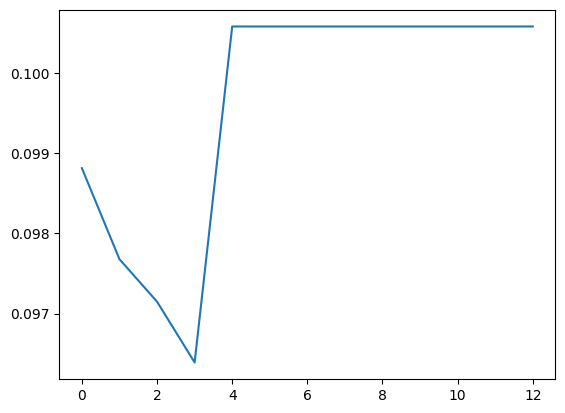

In [ ]:
loss_tn = loss_t.detach().cpu().numpy()
HI_dra = np.mean(loss_tn,axis = 1).reshape(-1)
plt.plot(HI_dra)

In [ ]:
 # aa = np.array([[1,2,3],[4,5,6]])
# aa

array([[1, 2, 3],
       [4, 5, 6]])

In [ ]:
# max_1 = np.max(aa,axis = 1)
# min_1 = np.min(aa,axis = 1)
# max_1

array([3, 6])

In [ ]:
def normalize(data):
  max_1 = np.max(data,axis = 1).reshape(-1,1)
  min_1 = np.min(data,axis = 1).reshape(-1,1)
  data_ = -1+2*(data-min_1)/(max_1-min_1)
  return data_

In [ ]:
# bb = normalize(aa)
# bb

array([[-1.,  0.,  1.],
       [-1.,  0.,  1.]])

In [ ]:

data_test = np.concatenate((normalize(ae_spindle_w[1:16,:]),normalize(ae_table_w[1:16,:]),normalize(vib_spindle_w[1:16,:]),normalize(vib_table_w[1:16,:]),normalize(smcAC_w[1:16,:]),normalize(smcDC_w[1:16,:])),axis=0)




### Training the model using the time-domain data

In [ ]:
model.eval()
ta = torch.arange(0,1000)
loss_t = torch.rand(9,1000)


ta = torch.arange(1000)
# for i in range(984):
#     print(i)
for i in range(984):
    for t in ta:
    # temp[0,:] = x_t[5*i,:]
        print(t.item())
        loss_t[i,t] = diffusion_loss_t(model,data_te[i,:], t,alphas_bar_sqrt, one_minus_alphas_bar_sqrt)



### 9. Construction of the Health indicator and the anomaly map

#### 9.1 use the envelope spectrum to get the anomaly map


Try to build anomaly map

1. use the forward propagation
